**Goal:** build a movie recommender from nothing but a table of ratings -- no
recommender library. You will construct the user-item matrix, find similar users
and items with cosine similarity, predict ratings and score them with RMSE/MAE,
make a demographic recommendation, and (optionally) train a small matrix
factorization model whose latent factors are the same idea you met in L14's PCA.
Pairs with the concept note
[Recommender Systems: How Machines Suggest](l15_concept_recommender_systems.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l15_lab_movie_recommenders.ipynb`) -- in Colab via the badge on the concept
> page, or locally. Needs network access the first time (it downloads MovieLens 100k).

## Prerequisites & Setup

We use **MovieLens 100k** (GroupLens, University of Minnesota): 100,000 ratings
(1-5 stars) from 943 users on 1,682 movies, plus user demographics and movie
genres. Its license **forbids redistribution**, so -- unlike every other lab in
this course -- we do **not** bundle the data; the notebook downloads it from
GroupLens at run time and checks its md5. Please use it for learning only and
cite Harper & Konstan (2015).

In [1]:
# Install packages -- its OWN cell (run once; required for Colab, which resets on open).
%pip install -q pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports + data. Safe to re-run without re-installing anything above.
import os, hashlib, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MovieLens 100k -- downloaded at run time; NOT redistributed (license forbids it).
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
MD5 = "0e33842e24a9c977be4e0107933c0723"
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/ml-100k/u.data"):
    urllib.request.urlretrieve(URL, "data/ml-100k.zip")
    assert hashlib.md5(open("data/ml-100k.zip", "rb").read()).hexdigest() == MD5, "checksum mismatch"
    with zipfile.ZipFile("data/ml-100k.zip") as z:
        z.extractall("data")

ratings = pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user", "item", "rating", "ts"])
users = pd.read_csv("data/ml-100k/u.user", sep="|", names=["user", "age", "gender", "occupation", "zip"])
GENRES = ["unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
          "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
          "Romance", "Sci-Fi", "Thriller", "War", "Western"]
items = pd.read_csv("data/ml-100k/u.item", sep="|", encoding="latin-1",
                    names=["item", "title", "release", "video", "imdb"] + GENRES)

print("MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.")
print("ratings:", ratings.shape, "| users:", users.shape, "| items:", items.shape)

MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)


<details><summary>Expected Output</summary>

~~~text
MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)
~~~
</details>

## Step 1: The Ratings Matrix (Worked)

A recommender starts from one object: the **user-item matrix** $R$, where $R_{ui}$
is the rating user $u$ gave item $i$. Almost every cell is empty -- nobody rates
more than a sliver of all movies. That emptiness (**sparsity**) is the whole
problem.

In [3]:
R = ratings.pivot(index="user", columns="item", values="rating")
R = R.reindex(index=range(1, 944), columns=range(1, 1683))   # full 943 x 1682 grid
n_users, n_items = R.shape
filled = ratings.shape[0]
sparsity = 100 * (1 - filled / (n_users * n_items))
print(f"ratings matrix: {n_users} users x {n_items} movies")
print(f"filled cells: {filled}  ({100 - sparsity:.1f}% filled, {sparsity:.1f}% empty)")

ratings matrix: 943 users x 1682 movies
filled cells: 100000  (6.3% filled, 93.7% empty)


<details><summary>Expected Output</summary>

~~~text
ratings matrix: 943 users x 1682 movies
filled cells: 100000  (6.3% filled, 93.7% empty)
~~~
</details>

Seeing that emptiness helps. The cell below draws a 60x80 corner of the matrix --
blue where a rating exists, white where it is missing.

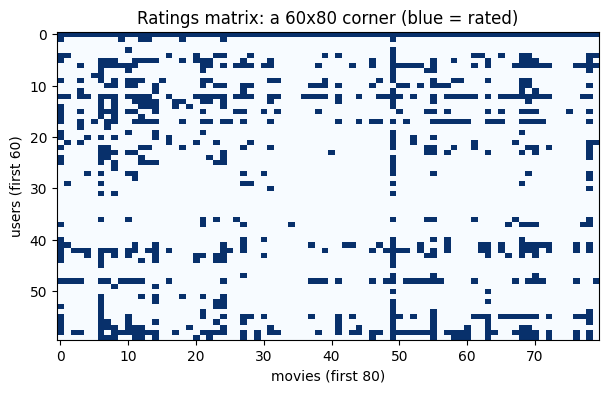

In [4]:
plt.figure(figsize=(7, 4))
plt.imshow(~np.isnan(R.values[:60, :80].astype(float)), aspect="auto", cmap="Blues")
plt.xlabel("movies (first 80)"); plt.ylabel("users (first 60)")
plt.title("Ratings matrix: a 60x80 corner (blue = rated)")
plt.show()

### Naive approach: just recommend the most popular   <!-- M7: the slow/wrong way first -->

The simplest "recommender" ignores *you* entirely and shows everyone the same
crowd-pleasers: the highest-rated movies (with enough ratings to be trustworthy).

In [5]:
stats = ratings.groupby("item").rating.agg(["count", "mean"])
popular = (stats[stats["count"] >= 50]
           .sort_values("mean", ascending=False).head(5)
           .join(items.set_index("item")["title"]))
print(popular[["title", "mean", "count"]].round(2).to_string(index=False))

                                                 title  mean  count
                                 Close Shave, A (1995)  4.49    112
                               Schindler's List (1993)  4.47    298
                            Wrong Trousers, The (1993)  4.47    118
                                     Casablanca (1942)  4.46    243
Wallace & Gromit: The Best of Aardman Animation (1996)  4.45     67


<details><summary>Expected Output</summary>

~~~text
                                                 title  mean  count
                                 Close Shave, A (1995)  4.49    112
                               Schindler's List (1993)  4.47    298
                            Wrong Trousers, The (1993)  4.47    118
                                     Casablanca (1942)  4.46    243
Wallace & Gromit: The Best of Aardman Animation (1996)  4.45     67
~~~
</details>

Fine list -- but it is the *same* for every user. Personalization needs the
ratings of people like you. That is collaborative filtering.

## Step 2: User-User Collaborative Filtering (Worked)

**Collaborative filtering** predicts your taste from the crowd: find users who
rated movies the way you did, then recommend what *they* liked that you have not
seen. "Rated the way you did" needs a similarity measure. We use **cosine
similarity** between two users' rating vectors $a$ and $b$:

$$\cos(a, b) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

First we **mean-center** each user (subtract their average) so a generous rater
and a harsh rater can still look similar, and treat unrated movies as 0.

In [6]:
Rv = R.values.astype(float)
rated = ~np.isnan(Rv)                      # boolean: which cells have a rating
user_mean = np.nanmean(Rv, axis=1)         # each user's average (over rated movies)
Rc = np.where(rated, Rv - user_mean[:, None], 0.0)   # mean-centered; unrated -> 0
norm = np.sqrt((Rc**2).sum(axis=1)); norm[norm == 0] = 1e-9
sim = (Rc @ Rc.T) / np.outer(norm, norm)   # 943 x 943 cosine similarities
np.fill_diagonal(sim, 0.0)                 # a user is not their own neighbor
print("user-user similarity matrix:", sim.shape)

user-user similarity matrix: (943, 943)


<details><summary>Expected Output</summary>

~~~text
user-user similarity matrix: (943, 943)
~~~
</details>

To recommend for a user: take their $k$ most similar neighbors, and score each
unseen movie by the neighbors' similarity-weighted, mean-centered ratings.

In [7]:
def recommend_user_based(uid, k=30, n=5):
    u = uid - 1                                        # user ids are 1-based
    neighbors = np.argsort(-sim[u])[:k]                # k most similar users
    w = sim[u, neighbors]
    num = w @ Rc[neighbors]                            # weighted sum of their (centered) ratings
    den = np.abs(w) @ rated[neighbors].astype(float)   # total weight that actually rated each movie
    scores = user_mean[u] + np.divide(num, den, out=np.full(n_items, -np.inf), where=den > 0)
    scores[rated[u]] = -np.inf                         # drop movies u already rated
    top = np.argsort(-scores)[:n]
    return [(items.set_index("item").loc[i + 1, "title"], scores[i]) for i in top]

for title, score in recommend_user_based(196):
    print(f"{score:.2f}  {title}")

5.47  Andre (1994)
5.35  Apartment, The (1960)
5.35  Old Yeller (1957)
5.12  Story of Xinghua, The (1993)
5.12  Bean (1997)


<details><summary>Expected Output</summary>

~~~text
5.47  Andre (1994)
5.35  Apartment, The (1960)
5.35  Old Yeller (1957)
5.12  Story of Xinghua, The (1993)
5.12  Bean (1997)
~~~
</details>

> **Interpretation:** these are personalized to user 196's neighbors, not the
> global crowd-pleasers from Step 1. The scores can sit a little above 5 -- they
> are *ranking* scores (a mean plus a weighted bump), not calibrated star
> predictions. For ranking that is fine; when we need an actual predicted rating
> (next step), we clip to the 1-5 scale.

## Step 3: Predicting & Scoring Ratings (Worked + Completion)

To know whether a recommender is any good, hide some ratings, predict them, and
measure the error. We split the ratings into a training set and a test set
(the same `train_test_split` you used in L11), then compare predictions on the
held-out test ratings with two standard error metrics:

- **RMSE** (root mean squared error): $\sqrt{\text{mean}((\hat r - r)^2)}$ -- punishes big misses hardest.
- **MAE** (mean absolute error): $\text{mean}(\lvert \hat r - r \rvert)$ -- the average miss, in stars.

In [8]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

def rmse_mae(pred, true):
    pred = np.clip(pred, 1, 5)               # ratings live on a 1-5 scale
    err = pred - true
    return np.sqrt((err**2).mean()), np.abs(err).mean()

global_mean = train.rating.mean()
item_mean = train.groupby("item").rating.mean()
true = test.rating.values

rmse_g, mae_g = rmse_mae(np.full(len(test), global_mean), true)
rmse_i, mae_i = rmse_mae(test.item.map(item_mean).fillna(global_mean).values, true)
print(f"global-mean baseline: RMSE={rmse_g:.3f}  MAE={mae_g:.3f}")
print(f"item-mean baseline:   RMSE={rmse_i:.3f}  MAE={mae_i:.3f}")

global-mean baseline: RMSE=1.124  MAE=0.942
item-mean baseline:   RMSE=1.021  MAE=0.812


<details><summary>Expected Output</summary>

~~~text
global-mean baseline: RMSE=1.124  MAE=0.942
item-mean baseline:   RMSE=1.021  MAE=0.812
~~~
</details>

**Your completion problem:** add the third baseline -- predict each test rating
with that *user's* training average. Uncomment, fill the `____`, and run.

In [9]:
# Uncomment and fill the ____ : the user-mean baseline predicts each test rating
# with that USER's average from the training set (fall back to the global mean).
# user_mean_tr = train.groupby("user").rating.____()
# pred_u = test.user.map(user_mean_tr).fillna(global_mean).values
# rmse_u, mae_u = rmse_mae(pred_u, true)
# print(f"user-mean baseline:   RMSE={rmse_u:.3f}  MAE={mae_u:.3f}")

<details><summary>Expected Output (when completed correctly)</summary>

~~~text
user-mean baseline:   RMSE=1.042  MAE=0.835
~~~
</details>

Now the real thing: **item-item collaborative filtering**. Predict a (user,
movie) rating from how the user rated *similar movies*. Item-item similarity is
the same cosine, computed across the movie columns (this is "adjusted cosine":
we keep the user mean-centering so a movie's signal is the deviation from each
rater's norm).

In [10]:
Rtr = (train.pivot(index="user", columns="item", values="rating")
       .reindex(index=range(1, 944), columns=range(1, 1683)).values)
rated_tr = ~np.isnan(Rtr)
umean_tr = np.where(rated_tr.any(1),
                    np.nan_to_num(np.nanmean(np.where(rated_tr, Rtr, np.nan), axis=1)),
                    global_mean)
Rc_tr = np.where(rated_tr, Rtr - umean_tr[:, None], 0.0)
item_norm = np.sqrt((Rc_tr**2).sum(axis=0)); item_norm[item_norm == 0] = 1e-9
S = (Rc_tr.T @ Rc_tr) / np.outer(item_norm, item_norm)   # 1682 x 1682 item-item cosine
np.fill_diagonal(S, 0.0)

num = Rc_tr @ S                                  # for each (user, movie): weighted neighbor sum
den = rated_tr.astype(float) @ np.abs(S)         # total similarity weight the user actually rated
pred_all = umean_tr[:, None] + np.divide(num, den, out=np.zeros_like(num), where=den > 0)

pred_cf = np.array([pred_all[u - 1, i - 1] for u, i in zip(test.user, test.item)])
pred_cf = np.where(np.isfinite(pred_cf) & (pred_cf != 0), pred_cf, global_mean)
rmse_cf, mae_cf = rmse_mae(pred_cf, true)
print(f"item-item CF:         RMSE={rmse_cf:.3f}  MAE={mae_cf:.3f}")

item-item CF:         RMSE=0.945  MAE=0.743


<details><summary>Expected Output</summary>

~~~text
item-item CF:         RMSE=0.945  MAE=0.743
~~~
</details>

> **Interpretation:** every step beats the one before -- global mean (1.124) ->
> user mean (1.042, the rung you complete above) -> item mean (1.021) ->
> item-item CF (**0.945**). Knowing *which* movie helps; knowing how *this user*
> rates *similar* movies helps more.

## Step 4: A Demographic Recommendation (Worked)

When you know nothing about a brand-new user's ratings, you can still use *who
they are*. **Demographic filtering** recommends what people in the same group
liked. MovieLens ships real demographics in `u.user`, so we can ask: what do
women aged 25-34 rate highest?

In [11]:
dem = ratings.merge(users[["user", "gender", "age"]], on="user")
dem["age_group"] = pd.cut(dem.age, [0, 25, 35, 50, 100], labels=["<25", "25-34", "35-49", "50+"])
cohort = dem[(dem.gender == "F") & (dem.age_group == "25-34")]
cohort_top = (cohort.groupby("item").rating.agg(["count", "mean"])
              .query("count >= 20").sort_values("mean", ascending=False).head(5)
              .join(items.set_index("item")["title"]))
print("Top movies among women aged 25-34:")
print(cohort_top[["title", "mean", "count"]].round(2).to_string(index=False))

Top movies among women aged 25-34:
                           title  mean  count
Shawshank Redemption, The (1994)  4.78     23
      Usual Suspects, The (1995)  4.74     23
         Schindler's List (1993)  4.62     24
   Much Ado About Nothing (1993)  4.50     20
Silence of the Lambs, The (1991)  4.47     38


<details><summary>Expected Output</summary>

~~~text
Top movies among women aged 25-34:
                           title  mean  count
Shawshank Redemption, The (1994)  4.78     23
      Usual Suspects, The (1995)  4.74     23
         Schindler's List (1993)  4.62     24
   Much Ado About Nothing (1993)  4.50     20
Silence of the Lambs, The (1991)  4.47     38
~~~
</details>

> **Interpretation:** no ratings from the target user were needed -- only their
> group. That is exactly how demographic filtering survives the **cold-start**
> problem that sinks collaborative filtering for new users.

## Step 5 (Optional): Matrix Factorization from Scratch

This is the idea that won the Netflix Prize, and it is **L14's PCA in disguise**.
Instead of comparing whole rating vectors, we learn a short **latent vector** for
each user and each movie -- say $K = 20$ hidden "taste" dimensions -- so that
$\hat r_{ui} = \mu + b_u + b_i + p_u \cdot q_i$. We fit $p_u$ and $q_i$ by
**stochastic gradient descent** on the observed ratings only. (This cell runs a
real training loop -- give it up to a minute.)

In [12]:
user_ids = {u: k for k, u in enumerate(sorted(ratings.user.unique()))}
item_ids = {i: k for k, i in enumerate(sorted(ratings.item.unique()))}
train_arr = np.array([[user_ids[u], item_ids[i], r] for u, i, r in train[["user", "item", "rating"]].values])
test_arr = np.array([[user_ids[u], item_ids[i], r] for u, i, r in test[["user", "item", "rating"]].values])

rng = np.random.default_rng(42)
K, lr, reg, epochs = 20, 0.01, 0.05, 20
P = rng.normal(0, 0.1, (len(user_ids), K))      # user latent factors
Q = rng.normal(0, 0.1, (len(item_ids), K))      # movie latent factors
bu = np.zeros(len(user_ids)); bi = np.zeros(len(item_ids)); gmean = train.rating.mean()

for epoch in range(epochs):
    rng.shuffle(train_arr)
    for u, i, r in train_arr:
        u, i = int(u), int(i)
        err = r - (gmean + bu[u] + bi[i] + P[u] @ Q[i])
        bu[u] += lr * (err - reg * bu[u]); bi[i] += lr * (err - reg * bi[i])
        Pu = P[u].copy()
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * Pu - reg * Q[i])

ui = test_arr[:, 0].astype(int); ii = test_arr[:, 1].astype(int)
pred_mf = gmean + bu[ui] + bi[ii] + (P[ui] * Q[ii]).sum(axis=1)
rmse_mf, mae_mf = rmse_mae(pred_mf, test_arr[:, 2])
print(f"matrix factorization (K=20): RMSE={rmse_mf:.3f}  MAE={mae_mf:.3f}")

matrix factorization (K=20): RMSE=0.922  MAE=0.725


<details><summary>Expected Output</summary>

~~~text
matrix factorization (K=20): RMSE=0.922  MAE=0.725
~~~
</details>

> **Interpretation:** 20 learned factors per user and per movie beat item-item CF
> (0.922 vs 0.945) while storing far less than a 1682 x 1682 similarity matrix.
> Each row of `P` is a user's coordinates in a hidden taste space -- the same
> kind of low-dimensional embedding PCA gave you in L14, now learned directly
> from the ratings.

## Your Turn (Exercises)

### Exercise 1 - Recommend for another user -- **Hint:** call `recommend_user_based`

In [13]:
# TODO: pick any user id from 1..943 and print their top-5 user-based recommendations.

### Exercise 2 - Written: the cold-start problem
A brand-new user has just signed up and rated **nothing**. Explain in 2-3
sentences why `recommend_user_based` cannot help them yet, and which approach
from this lab (or the concept note) you would use instead, and why.

## Summary

- A recommender starts from the sparse **user-item matrix** (here 93.7% empty).
- **Collaborative filtering** turns the crowd into personalization via **cosine
  similarity** -- between users (Step 2) or items (Step 3) -- with no library.
- Hide ratings, predict, and score with **RMSE/MAE**; each idea beat the last
  (global 1.124 -> item 1.021 -> item-item CF 0.945 -> matrix factorization 0.922).
- **Demographic filtering** needs no ratings from the target user, so it survives
  **cold start**.
- **Matrix factorization** learns latent user/movie vectors -- L14's PCA idea,
  applied to recommendations.
- Next, **Unit VII** swaps the ratings matrix for a *graph*: social networks,
  communities, and neighborhoods of connections.